# Test Neurons

**Table of contents**<a id='toc0_'></a>    
- 1. [Imports](#toc1_)    
- 2. [Setup](#toc2_)    
- 3. [Neurons and layers](#toc3_)    
- 4. [Sample size](#toc4_)    
- 5. [Averaging](#toc5_)    
- 6. [Quadrature](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1. <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import torch
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [4]:
from EconDLSolvers import choose_gpu

In [5]:
from BufferStockModel import BufferStockModelClass

## 2. <a id='toc2_'></a>[Setup](#toc0_)

In [6]:
device = choose_gpu()

GPU 0: 44.40GB free [NVIDIA L40]
Best GPU: 0


In [7]:
algonames = ['DeepSimulate','DeepFOC','DeepVPD']
K = {'DeepSimulate':240,'DeepFOC':30,'DeepVPD':60}
Nneurons_value_base = np.array([1000,1000])
Nneurons_policy_base = np.array([1000,1000])

## 3. <a id='toc3_'></a>[Neurons and layers](#toc0_)

In [8]:
Nneuronss = [500,1000,2000]
Layers = [2,4,6]

In [9]:
results = []

for algo in algonames:

    print(f'Running algo {algo}')
    for Nneurons in Nneuronss:
        print(f'Using {Nneurons = }')      

        for Layer in Layers:
            print(f'Using {Layer = }')

            Nneurons_policy = np.array([Nneurons]*Layer)
            Nneurons_value = np.array([Nneurons]*Layer)

            model = BufferStockModelClass(
                algoname=algo,
                device=device,
                sim={'N':1},
                train={
                    'K':K[algo],'K_time':np.inf,
                    'Nneurons_policy':Nneurons_policy,'Nneurons_value':Nneurons_value,
                    'sim_R_freq':None,'epoch_termination':False,'start_train_policy':-1},
            )
            if hasattr(type(model),'add_transfer'): delattr(type(model),'add_transfer')

            model.solve(do_print_terminate=False)

            Nparams_policy = sum([np.prod(v.size()) for v in model.policy_NN.parameters()])
            if model.value_NN is None:
                Nparams_value = 0
            else:
                Nparams_value = sum([np.prod(v.size()) for v in model.value_NN.parameters()])

            results.append({
                'Algorithm': algo,
                'Nneurons': Nneurons,
                'Layers': Layer,
                'Nparams': Nparams_policy+Nparams_value,
                'time': model.info['time'],
                'time.update_NN': model.info['time.update_NN'],
                'time.update_NN.train_policy': model.info['time.update_NN.train_policy'],
                'time.update_NN.train_value': model.info['time.update_NN.train_value'],
                'time._simulate_training_sample': model.info['time._simulate_training_sample'],
                'time.update_best': model.info['time.update_best'],                
                'GB':torch.cuda.max_memory_allocated(device)/10**9
            })

            torch.cuda.reset_peak_memory_stats(device)

# convert results to a DataFrame
df = pd.DataFrame(results)

Running algo DeepSimulate
Using Nneurons = 500
Using Layer = 2


Using Layer = 4


Using Layer = 6


Using Nneurons = 1000
Using Layer = 2


Using Layer = 4


...

Using Layer = 4


Using Layer = 6


Using Nneurons = 2000
Using Layer = 2


Using Layer = 4


Using Layer = 6


DeepSimulate


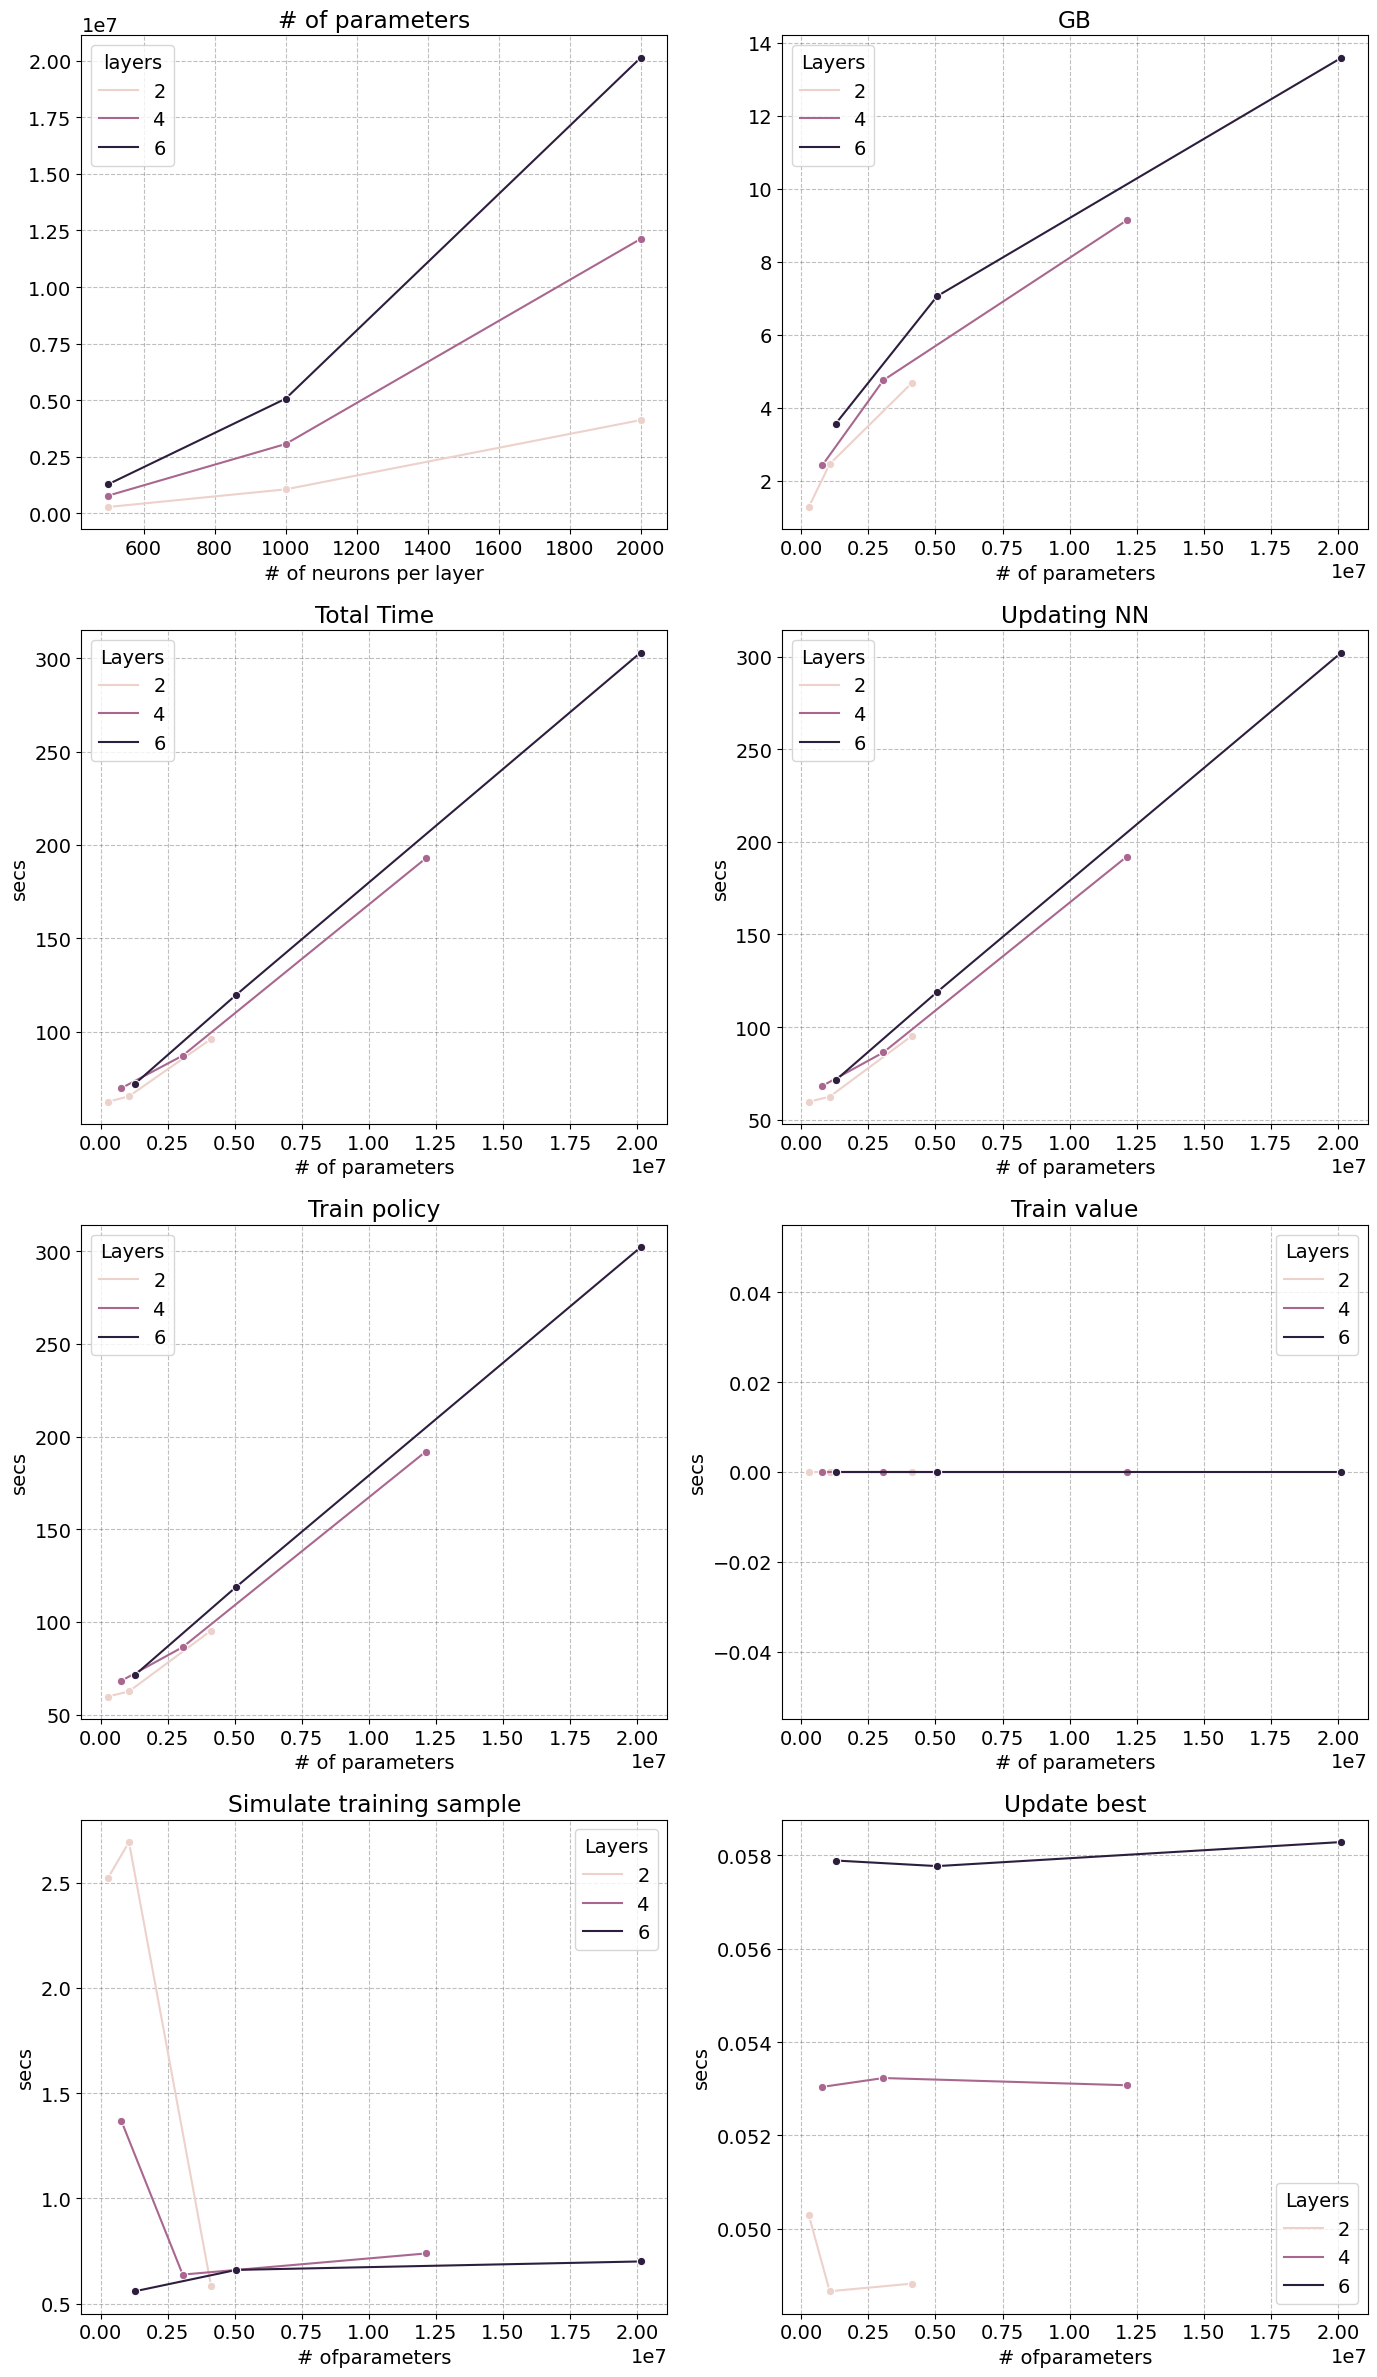

DeepFOC


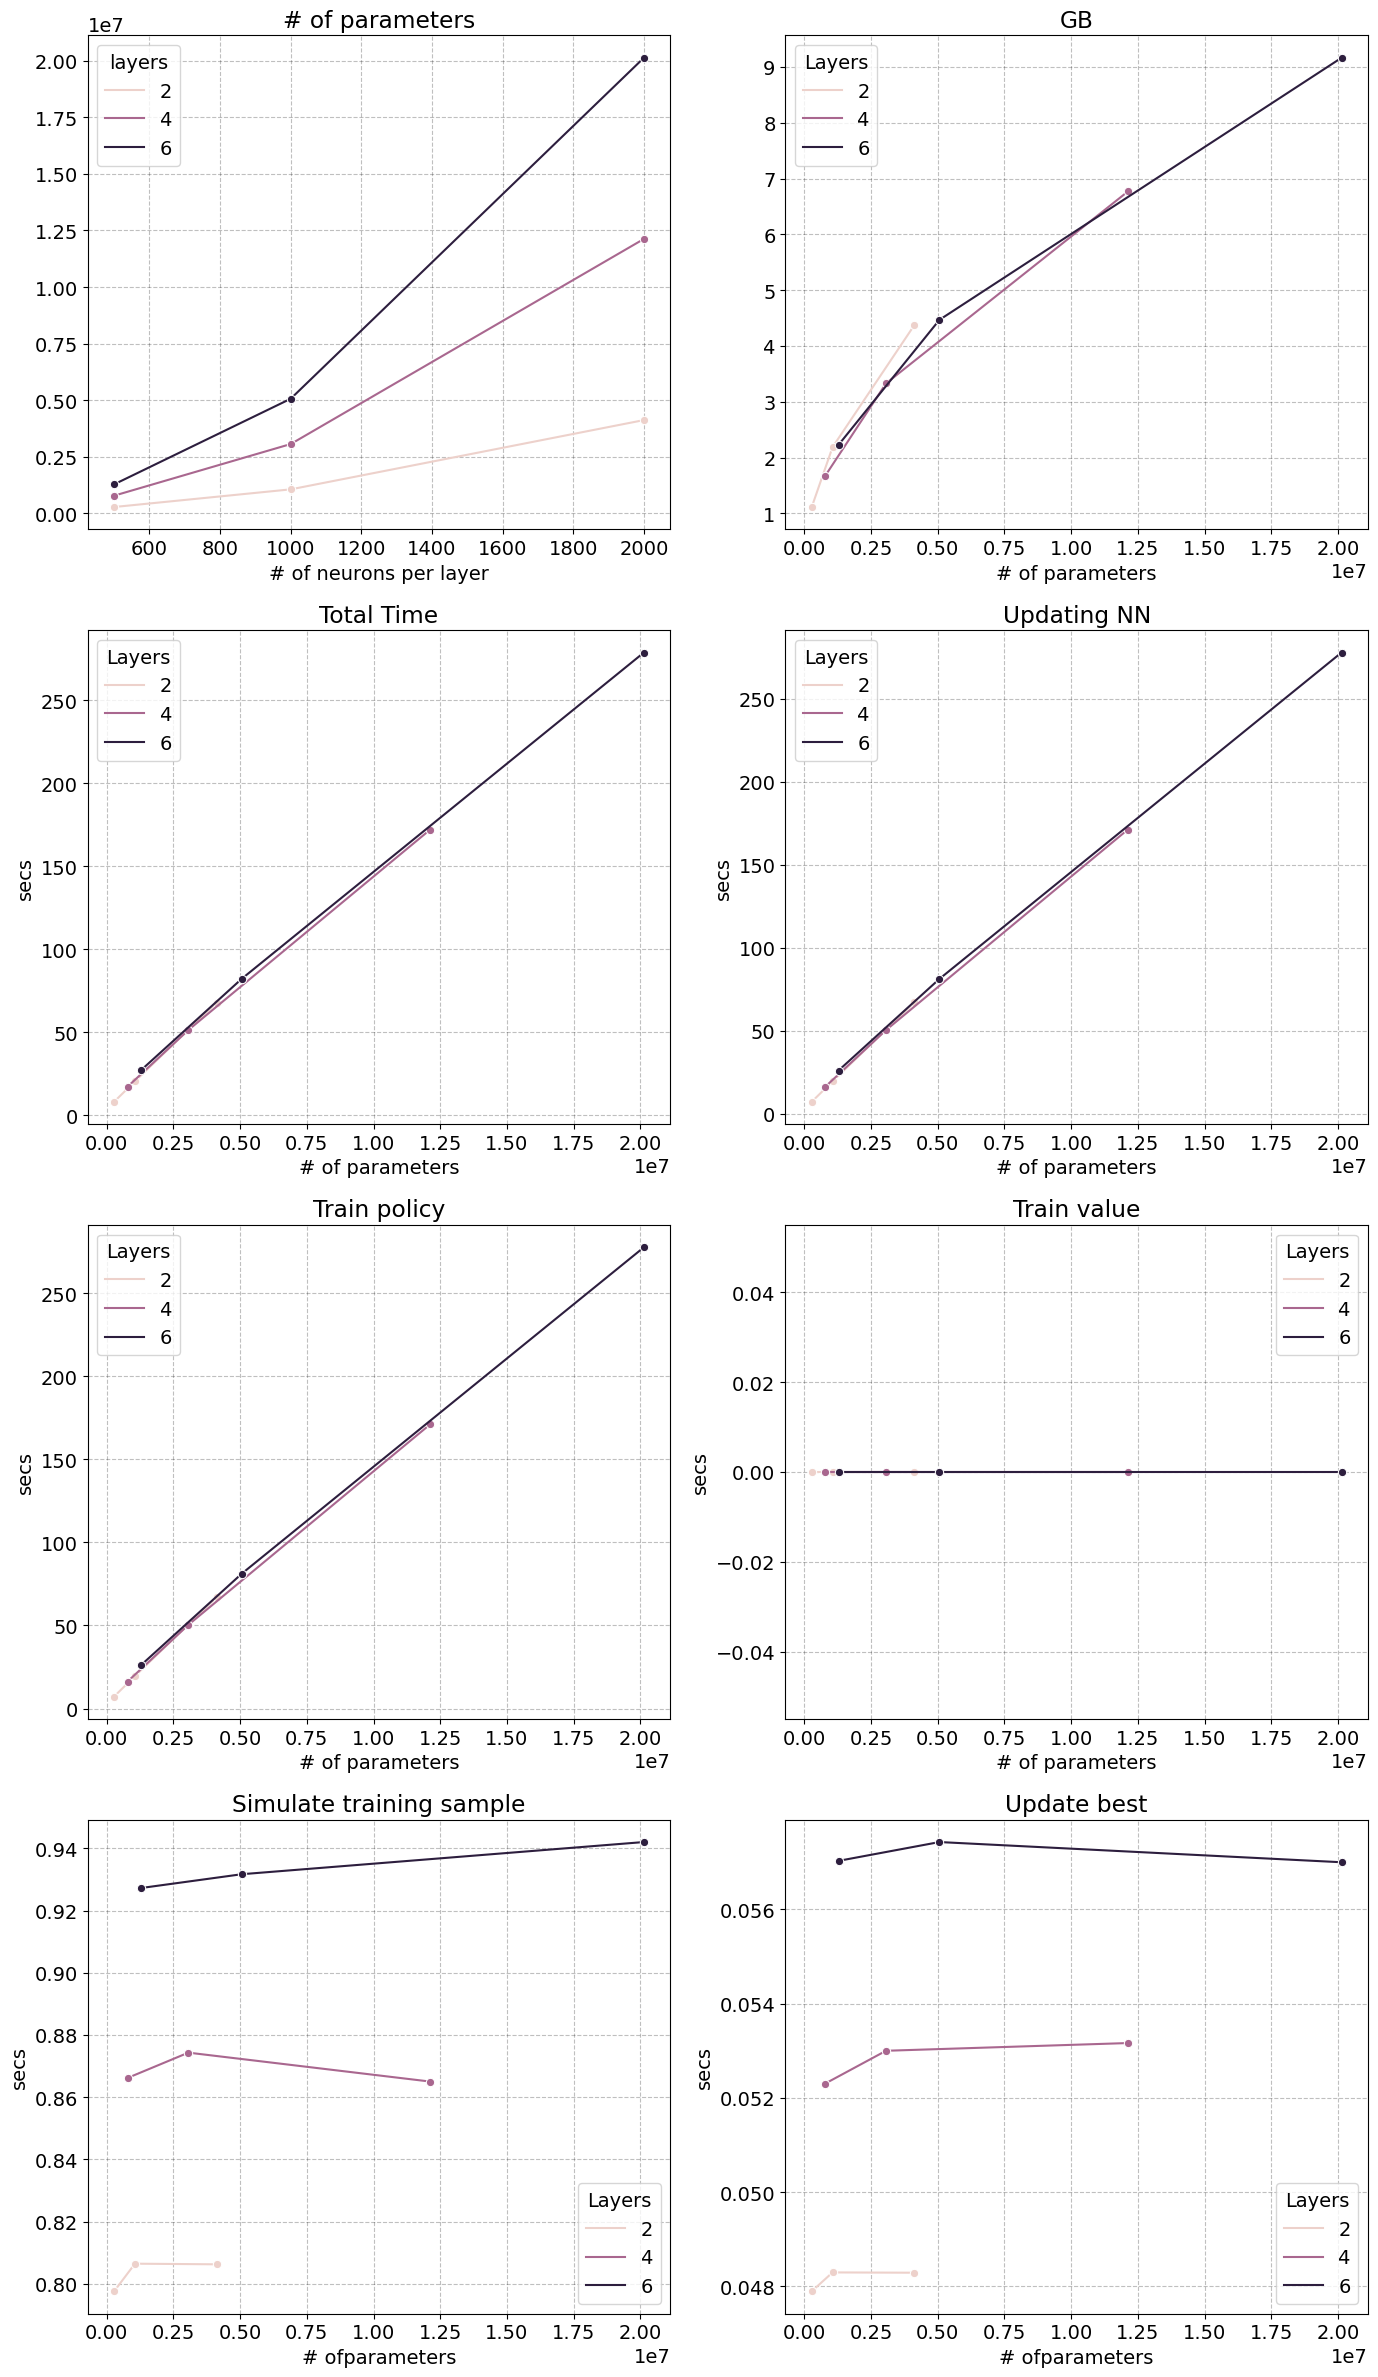

DeepVPD


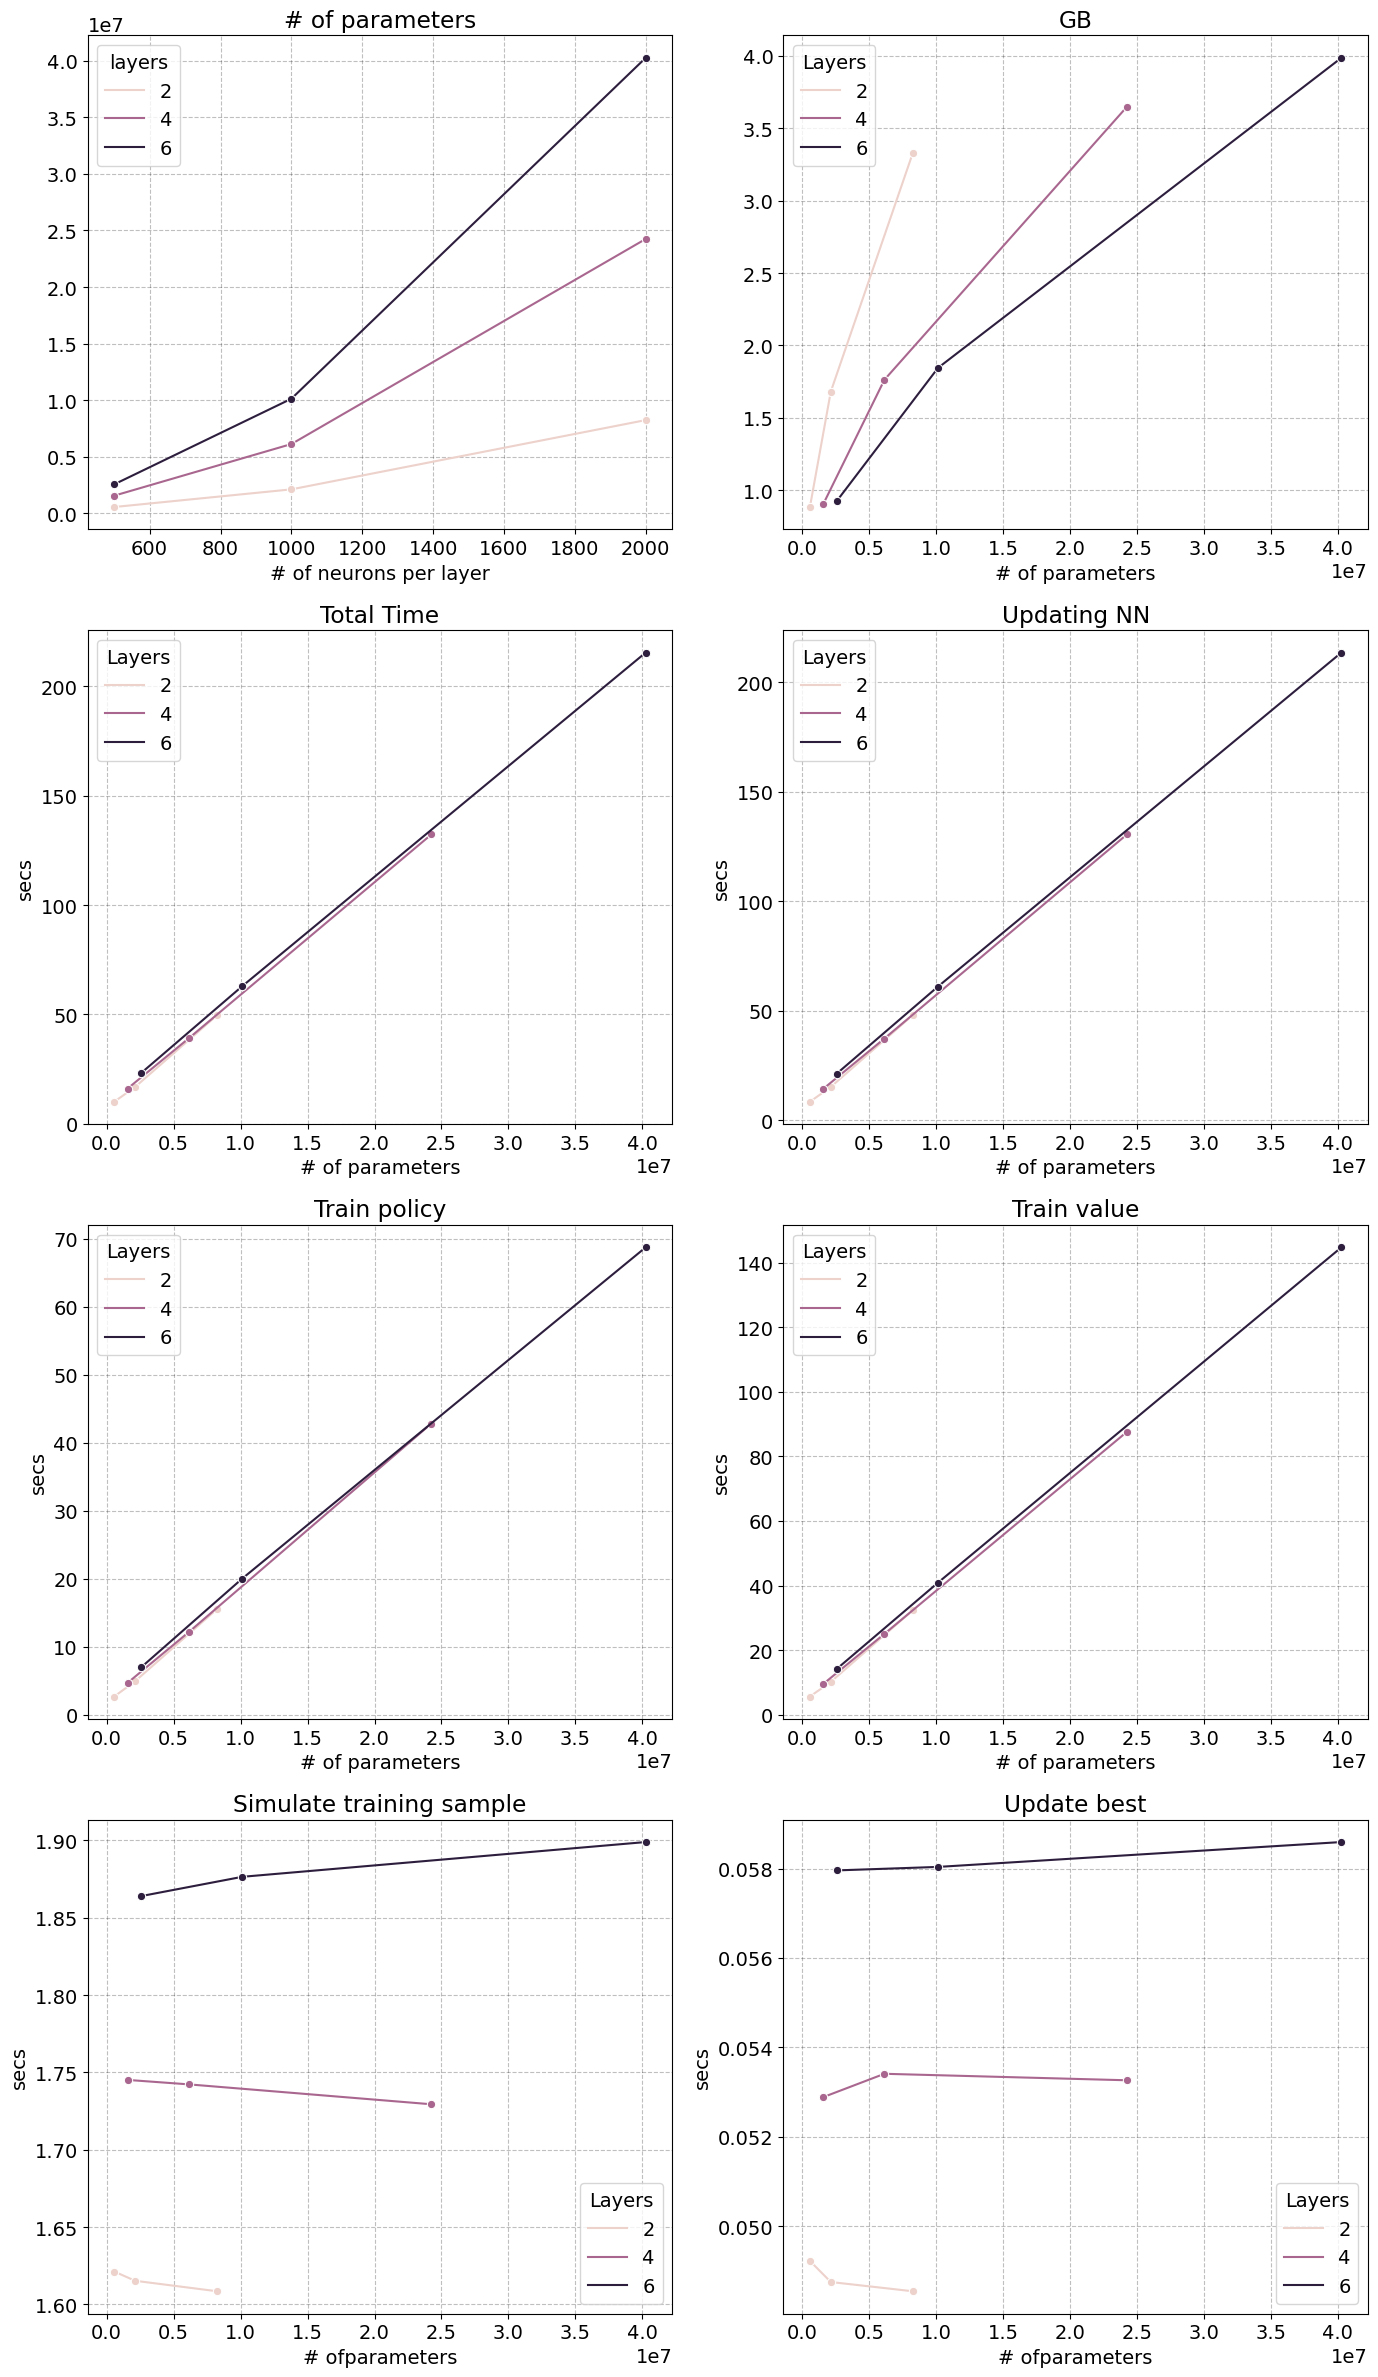

In [10]:
for algo in algonames:
    
    print(algo)
    
    # get data
    subset = df[df['Algorithm'] == algo]

    # create figure and subplots
    fig, axes = plt.subplots(4,2,figsize=(14,24))

    # Nparams
    sns.lineplot(
        data=subset, 
        x='Nneurons', 
        y='Nparams', 
        hue='Layers',
        marker='o',
        ax=axes[0,0]
    )
    axes[0,0].set_title(f'# of parameters')
    axes[0,0].set_ylabel('')
    axes[0,0].set_xlabel('# of neurons per layer')
    axes[0,0].legend(title='layers')
    axes[0,0].grid(True)

    # GB
    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='GB',
        hue='Layers',
        marker='o',
        ax=axes[0,1]
    )
    axes[0,1].set_title(f'GB')
    axes[0,1].set_ylabel('')
    axes[0,1].set_xlabel('# of parameters')
    axes[0,1].grid(True)
    
    # Time
    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time',
        hue='Layers',
        marker='o',
        ax=axes[1,0]
    )
    axes[1,0].set_title(f'Total Time')
    axes[1,0].set_ylabel('secs')
    axes[1,0].set_xlabel('# of parameters')
    axes[1,0].grid(True)

    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time.update_NN',
        hue='Layers',
        marker='o',
        ax=axes[1,1]
    )
    axes[1,1].set_title(f'Updating NN')
    axes[1,1].set_ylabel('secs')
    axes[1,1].set_xlabel('# of parameters')
    axes[1,1].grid(True)  

    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time.update_NN.train_policy',
        hue='Layers',
        marker='o',
        ax=axes[2,0]
    )
    axes[2,0].set_title(f'Train policy')
    axes[2,0].set_ylabel('secs')
    axes[2,0].set_xlabel('# of parameters')
    axes[2,0].grid(True)  

    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time.update_NN.train_value',
        hue='Layers',
        marker='o',
        ax=axes[2,1]
    )
    axes[2,1].set_title(f'Train value')
    axes[2,1].set_ylabel('secs')
    axes[2,1].set_xlabel('# of parameters')
    axes[2,1].grid(True)  

    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time._simulate_training_sample',
        hue='Layers',
        marker='o',
        ax=axes[3,0]
    )
    axes[3,0].set_title(f'Simulate training sample')
    axes[3,0].set_ylabel('secs')
    axes[3,0].set_xlabel('# ofparameters')
    axes[3,0].grid(True)  

    sns.lineplot(
        data=subset, 
        x='Nparams', 
        y='time.update_best',
        hue='Layers',
        marker='o',
        ax=axes[3,1]
    )
    axes[3,1].set_title(f'Update best')
    axes[3,1].set_ylabel('secs')
    axes[3,1].set_xlabel('# ofparameters')
    axes[3,1].grid(True)  

    plt.tight_layout()
    plt.show()      

## 4. <a id='toc4_'></a>[Sample size](#toc0_)

In [11]:
Ns = [100,250,500,1000]
Ns_simulate = [1000,2500,5000,10000]

In [12]:
results = []
for algo in algonames:

    print(f'Running algo {algo}')
    for N,N_simulate in zip(Ns,Ns_simulate):

        if algo == 'DeepSimulate': N = N_simulate
        print(f'Using {N = }')      

        model = BufferStockModelClass(
            algoname=algo,
            device=device,
            sim={'N':1},
            train={
                'K':K[algo],'K_time':np.inf, 
                'N':N,
                'batch_size':N,
                'Nneurons_policy':Nneurons_policy_base,'Nneurons_value':Nneurons_value_base,
                'sim_R_freq':None,'epoch_termination':False,'start_train_policy':-1},
        )
        if hasattr(type(model),'add_transfer'): delattr(type(model),'add_transfer')

        model.solve(do_print_terminate=False)

        results.append({
            'Algorithm': algo,
            'N': model.train.N,
            'batch_size': model.train.batch_size,
            'time': model.info['time'],
            'time.update_NN': model.info['time.update_NN'],
            'time.update_NN.train_policy': model.info['time.update_NN.train_policy'],
            'time.update_NN.train_value': model.info['time.update_NN.train_value'],
            'time._simulate_training_sample': model.info['time._simulate_training_sample'],
            'time.update_best': model.info['time.update_best'],            
            'GB':torch.cuda.max_memory_allocated(device)/10**9
        })

        torch.cuda.reset_peak_memory_stats(device)

# convert results to a DataFrame
df = pd.DataFrame(results)

Running algo DeepSimulate
Using N = 1000


Using N = 2500


Using N = 5000


Using N = 10000


Running algo DeepFOC
Using N = 100


...

Using N = 1000


Running algo DeepVPD
Using N = 100


Using N = 250


Using N = 500


Using N = 1000


DeepSimulate


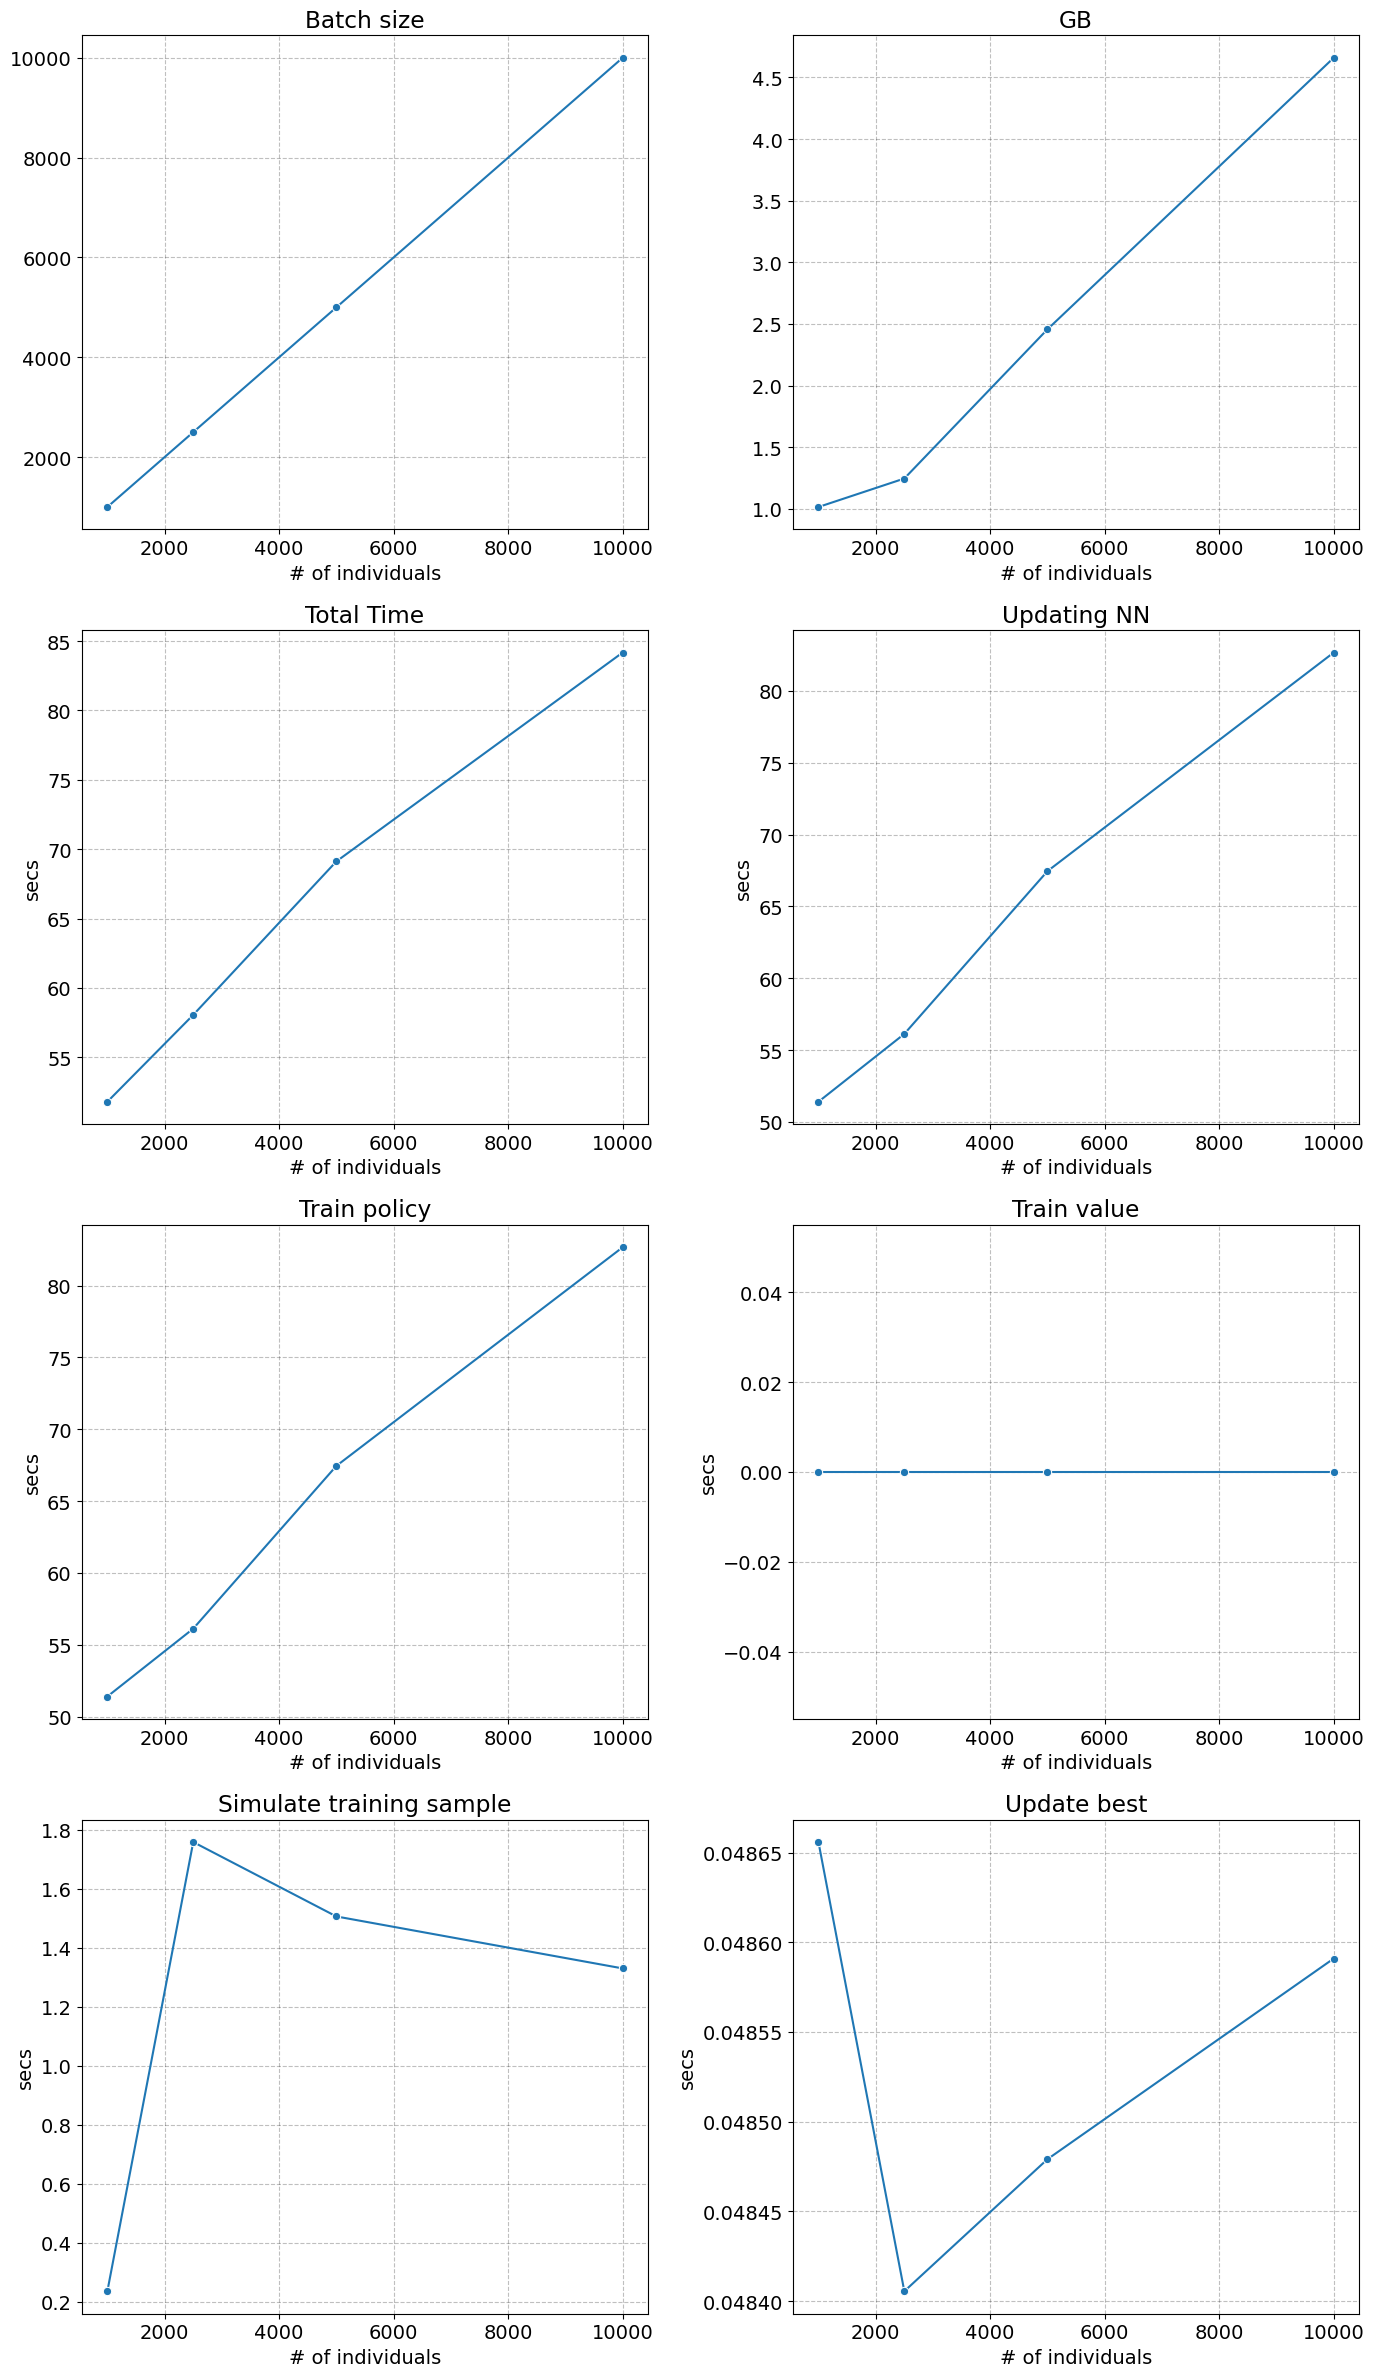

DeepFOC


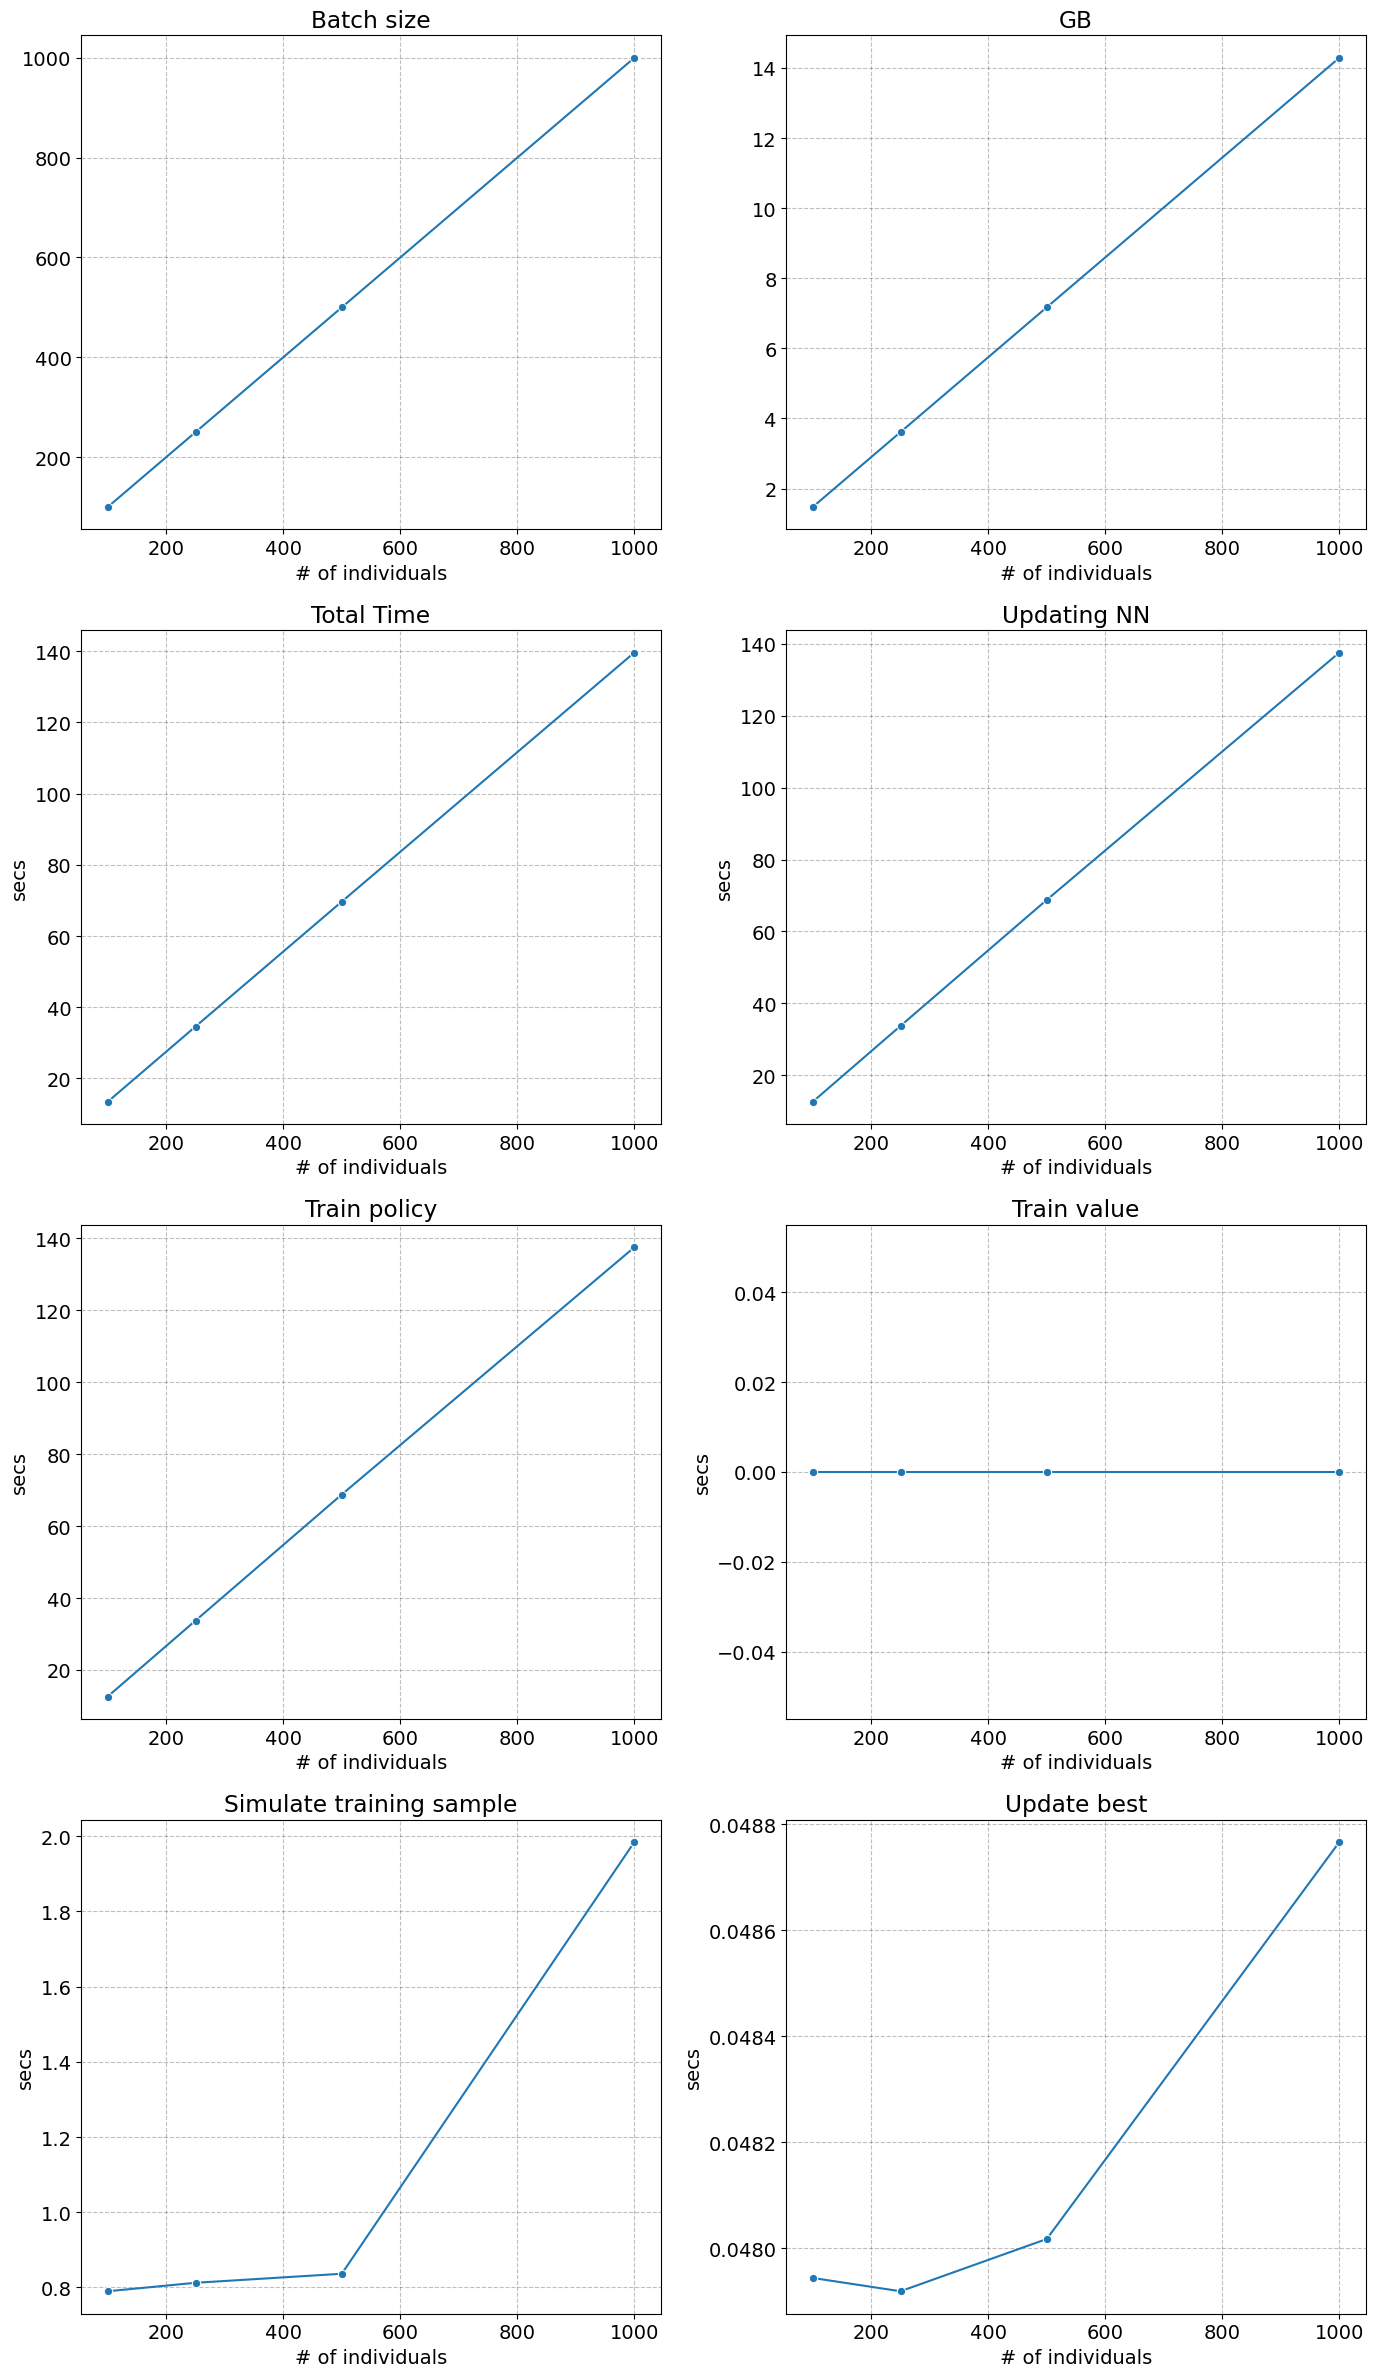

DeepVPD


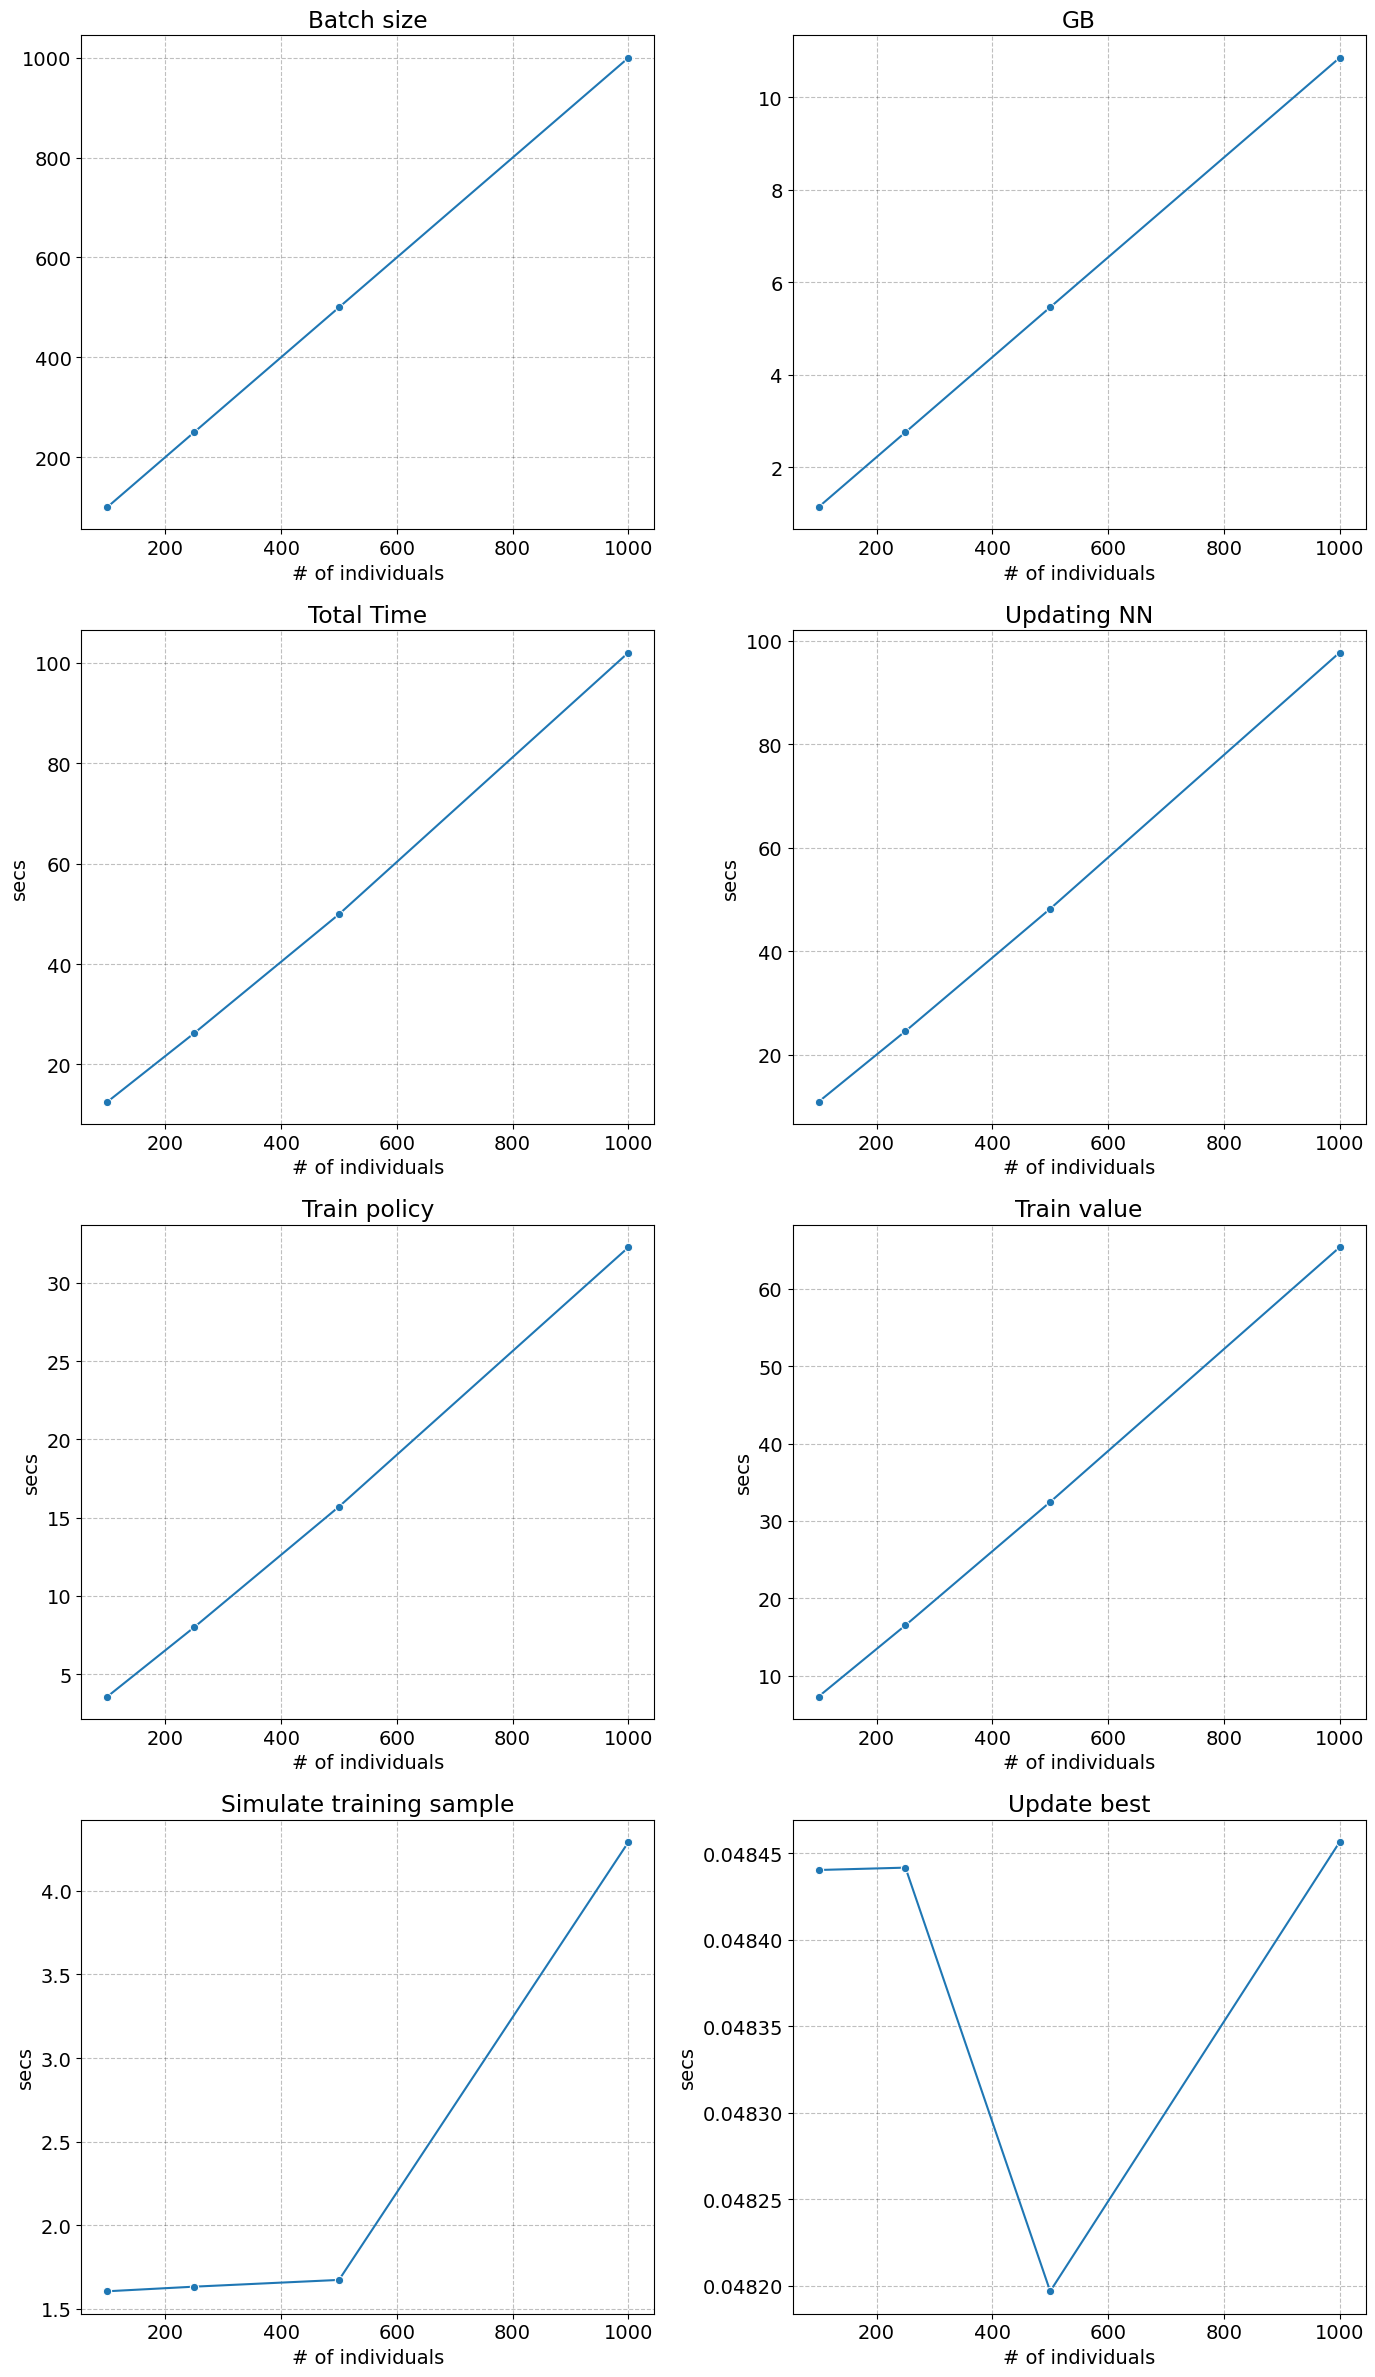

In [13]:
for algo in algonames:
    
    print(algo)
    
    # get data
    subset = df[df['Algorithm'] == algo]

    # create figure and subplots
    fig, axes = plt.subplots(4,2,figsize=(14,24))

    # batch size
    sns.lineplot(
        data=subset, 
        x='N', 
        y='batch_size',
        marker='o',
        ax=axes[0,0]
    )
    axes[0,0].set_title(f'Batch size')
    axes[0,0].set_ylabel('')
    axes[0,0].set_xlabel('# of individuals')
    axes[0,0].grid(True)

    # GB
    sns.lineplot(
        data=subset, 
        x='N', 
        y='GB',
        marker='o',
        ax=axes[0,1]
    )
    axes[0,1].set_title(f'GB')
    axes[0,1].set_ylabel('')
    axes[0,1].set_xlabel('# of individuals')
    axes[0,1].grid(True)
    
    # Time
    sns.lineplot(
        data=subset, 
        x='N', 
        y='time',
        marker='o',
        ax=axes[1,0]
    )
    axes[1,0].set_title(f'Total Time')
    axes[1,0].set_ylabel('secs')
    axes[1,0].set_xlabel('# of individuals')
    axes[1,0].grid(True)

    sns.lineplot(
        data=subset, 
        x='N', 
        y='time.update_NN',
        marker='o',
        ax=axes[1,1]
    )
    axes[1,1].set_title(f'Updating NN')
    axes[1,1].set_ylabel('secs')
    axes[1,1].set_xlabel('# of individuals')
    axes[1,1].grid(True)  

    sns.lineplot(
        data=subset, 
        x='N', 
        y='time.update_NN.train_policy',
        marker='o',
        ax=axes[2,0]
    )
    axes[2,0].set_title(f'Train policy')
    axes[2,0].set_ylabel('secs')
    axes[2,0].set_xlabel('# of individuals')
    axes[2,0].grid(True)  

    sns.lineplot(
        data=subset, 
        x='N', 
        y='time.update_NN.train_value',
        marker='o',
        ax=axes[2,1]
    )
    axes[2,1].set_title(f'Train value')
    axes[2,1].set_ylabel('secs')
    axes[2,1].set_xlabel('# of individuals')
    axes[2,1].grid(True)  

    sns.lineplot(
        data=subset, 
        x='N', 
        y='time._simulate_training_sample',
        marker='o',
        ax=axes[3,0]
    )
    axes[3,0].set_title(f'Simulate training sample')
    axes[3,0].set_ylabel('secs')
    axes[3,0].set_xlabel('# of individuals')
    axes[3,0].grid(True)  

    sns.lineplot(
        data=subset, 
        x='N', 
        y='time.update_best',
        marker='o',
        ax=axes[3,1]
    )
    axes[3,1].set_title(f'Update best')
    axes[3,1].set_ylabel('secs')
    axes[3,1].set_xlabel('# of individuals')
    axes[3,1].grid(True)  

    plt.tight_layout()
    plt.show()      


## 5. <a id='toc5_'></a>[Averaging](#toc0_)

In [14]:
N_value_NNs = [1,2,3,4,5]

In [15]:
results = []
algo = 'DeepVPD'
print(f'Running algo {algo}')

for N_value_NN in N_value_NNs:

    print(f'Using {N_value_NN = }')      

    model = BufferStockModelClass(
        algoname=algo,
        device=device,
        sim={'N':1},
        train={
            'K':K[algo],'K_time': np.inf,
            'N_value_NN':N_value_NN,
            'Nneurons_policy':Nneurons_policy_base,'Nneurons_value':Nneurons_value_base,
            'sim_R_freq':None,'epoch_termination':False,'start_train_policy':-1},
    )
    if hasattr(type(model),'add_transfer'): delattr(type(model),'add_transfer')

    model.solve(do_print_terminate=False)

    results.append({
        'Algorithm': algo,
        'N_value_NN': N_value_NN,
        'policy_epochs': model.info[('policy_epochs','sum')],
        'value_epochs': model.info[('value_epochs','sum')],
        'time': model.info['time'],
        'time.update_NN': model.info['time.update_NN'],
        'time.update_NN.train_policy': model.info['time.update_NN.train_policy'],
        'time.update_NN.train_value': model.info['time.update_NN.train_value'],
        'time._simulate_training_sample': model.info['time._simulate_training_sample'],
        'time.update_best': model.info['time.update_best'],
        'GB':torch.cuda.max_memory_allocated(device)/10**9
    })

    torch.cuda.reset_peak_memory_stats(device)

# convert results to a DataFrame
df = pd.DataFrame(results)

Running algo DeepVPD
Using N_value_NN = 1


Using N_value_NN = 2


Using N_value_NN = 3


Using N_value_NN = 4


Using N_value_NN = 5


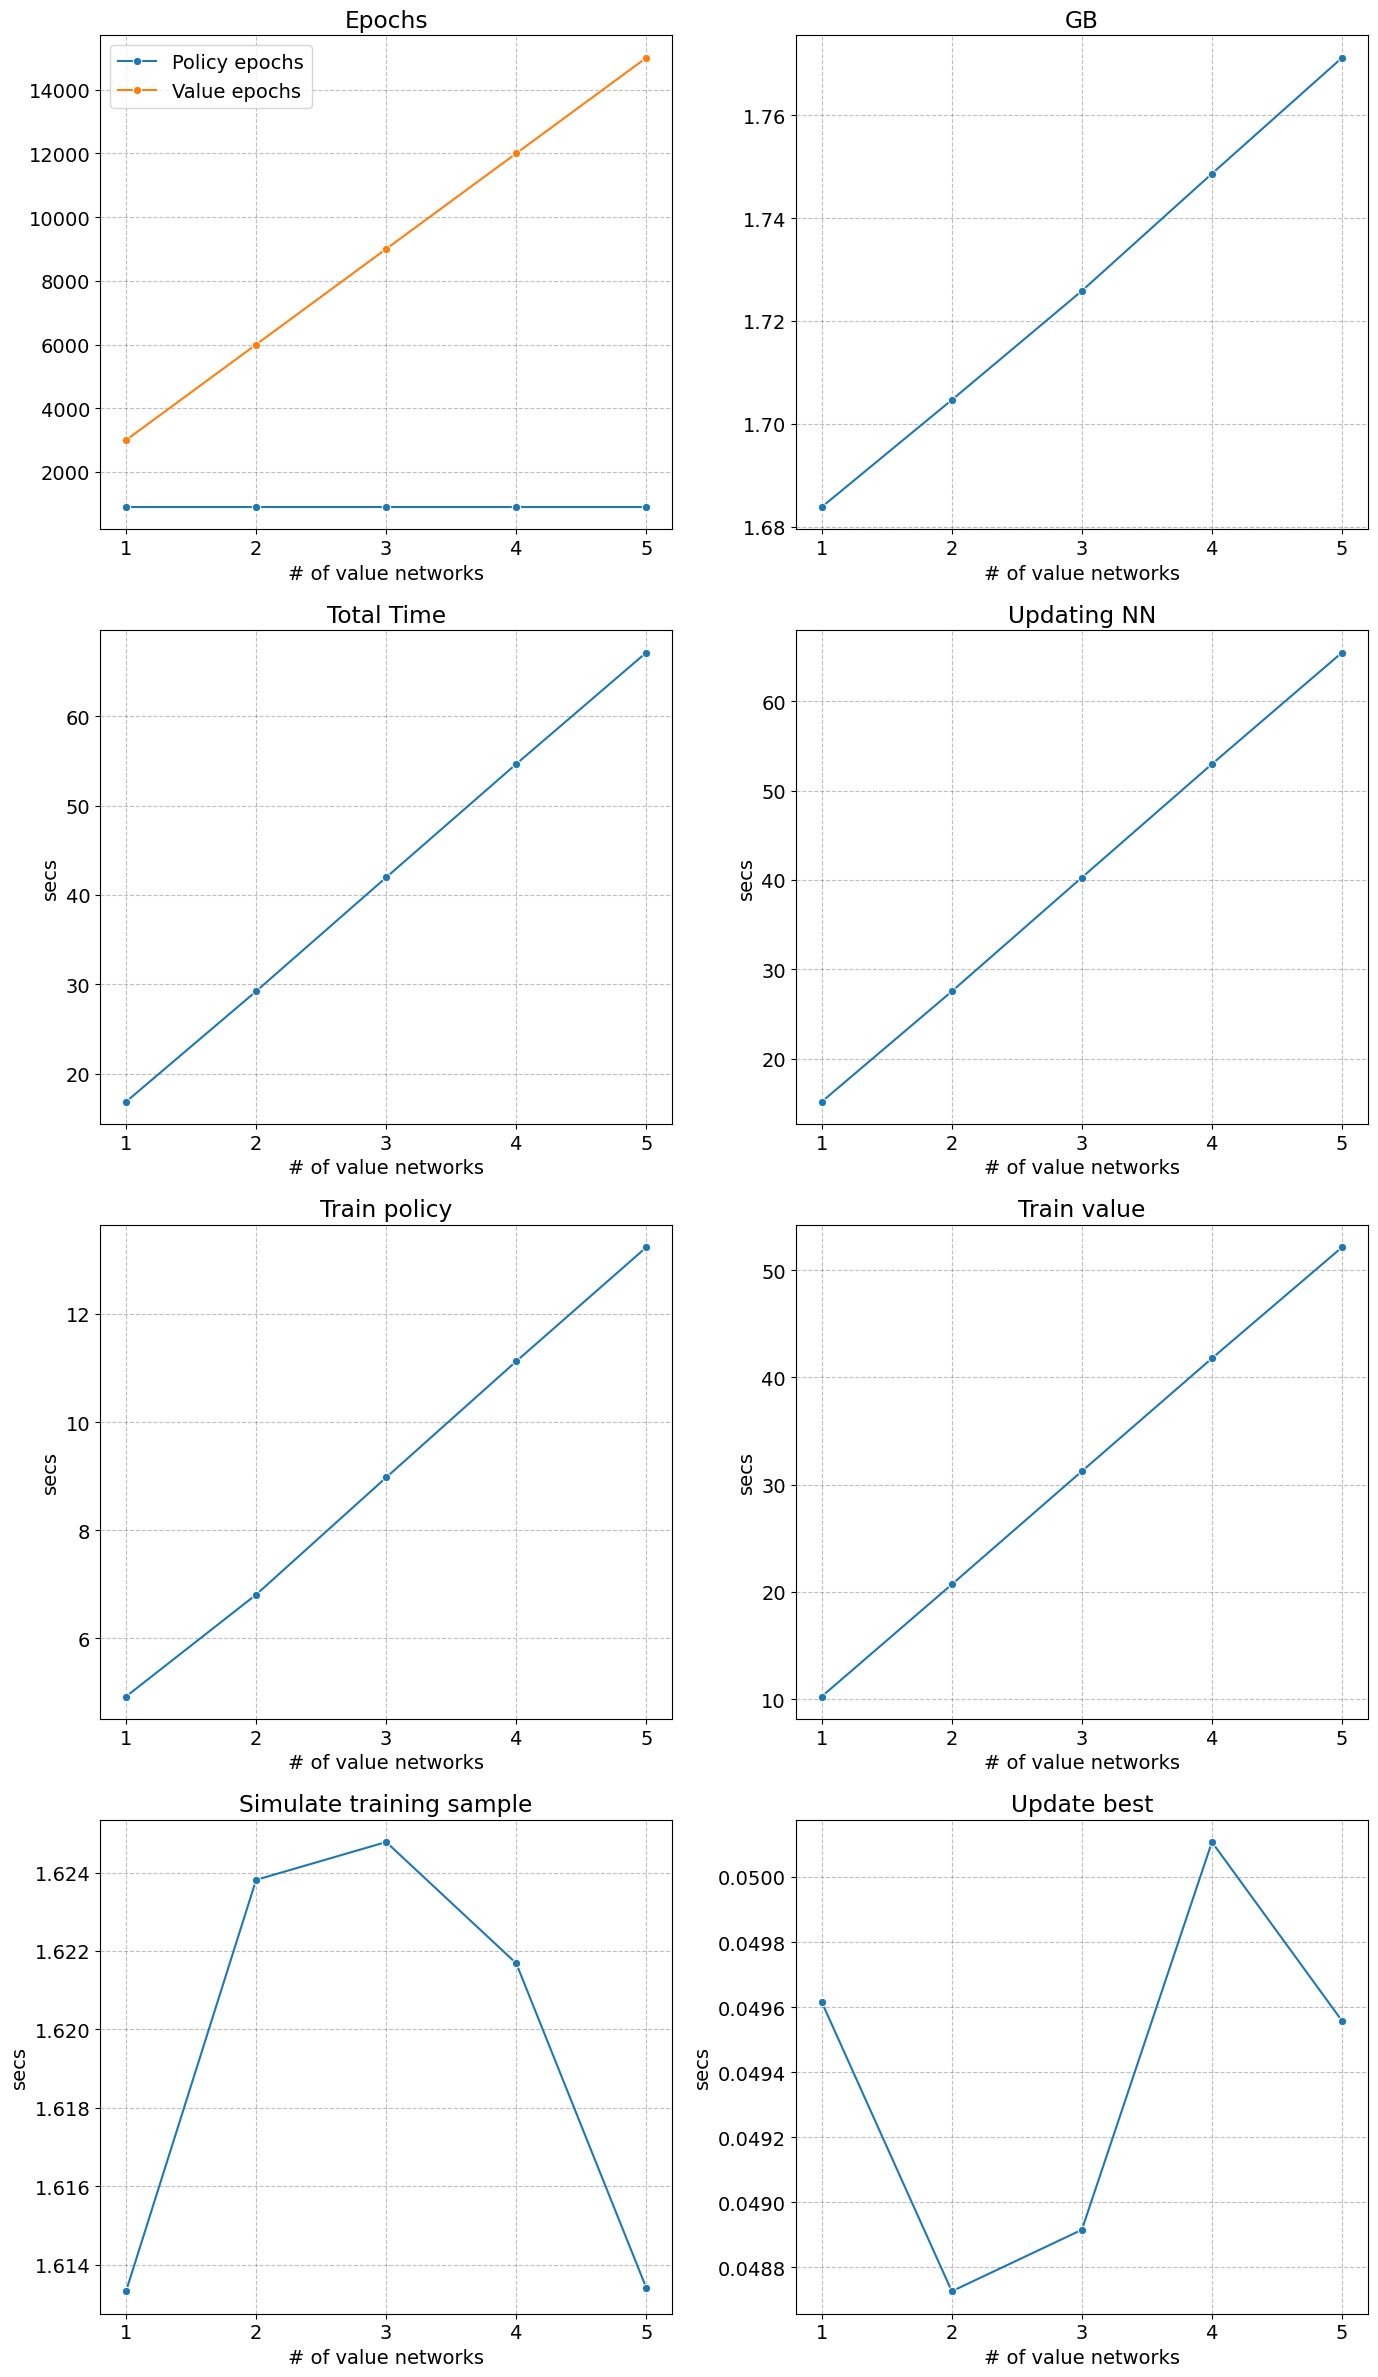

In [16]:
# get data
subset = df[df['Algorithm'] == algo]

# create figure and subplots
fig, axes = plt.subplots(4,2,figsize=(14,24))

# epochs
sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='policy_epochs',
    label='Policy epochs',
    marker='o',
    ax=axes[0,0],
)
g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='value_epochs',
    label='Value epochs',
    marker='o',
    ax=axes[0,0],
)    
g.set_xticks(N_value_NNs)
axes[0,0].set_title(f'Epochs')
axes[0,0].set_ylabel('')
axes[0,0].set_xlabel('# of value networks')
axes[0,0].grid(True)
axes[0,0].legend()

# GB
g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='GB',
    marker='o',
    ax=axes[0,1]
)
g.set_xticks(N_value_NNs)
axes[0,1].set_title(f'GB')
axes[0,1].set_ylabel('')
axes[0,1].set_xlabel('# of value networks')
axes[0,1].grid(True)

# Time
g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time',
    marker='o',
    ax=axes[1,0]
)
g.set_xticks(N_value_NNs)
axes[1,0].set_title(f'Total Time')
axes[1,0].set_ylabel('secs')
axes[1,0].set_xlabel('# of value networks')
axes[1,0].grid(True)

g= sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time.update_NN',
    marker='o',
    ax=axes[1,1]
)
g.set_xticks(N_value_NNs)
axes[1,1].set_title(f'Updating NN')
axes[1,1].set_ylabel('secs')
axes[1,1].set_xlabel('# of value networks')
axes[1,1].grid(True)  

g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time.update_NN.train_policy',
    marker='o',
    ax=axes[2,0]
)
g.set_xticks(N_value_NNs)
axes[2,0].set_title(f'Train policy')
axes[2,0].set_ylabel('secs')
axes[2,0].set_xlabel('# of value networks')
axes[2,0].grid(True)  

g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time.update_NN.train_value',
    marker='o',
    ax=axes[2,1]
)
axes[2,1].set_title(f'Train value')
axes[2,1].set_ylabel('secs')
axes[2,1].set_xlabel('# of value networks')
axes[2,1].grid(True)  
g.set_xticks(N_value_NNs)

g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time._simulate_training_sample',
    marker='o',
    ax=axes[3,0]
)
g.set_xticks(N_value_NNs)
axes[3,0].set_title(f'Simulate training sample')
axes[3,0].set_ylabel('secs')
axes[3,0].set_xlabel('# of value networks')
axes[3,0].grid(True)  

g = sns.lineplot(
    data=subset, 
    x='N_value_NN', 
    y='time.update_best',
    marker='o',
    ax=axes[3,1]
)
axes[3,1].set_title(f'Update best')
axes[3,1].set_ylabel('secs')
axes[3,1].set_xlabel('# of value networks')
axes[3,1].grid(True)  
g.set_xticks(N_value_NNs)

plt.tight_layout()
plt.show()      


## 6. <a id='toc6_'></a>[Quadrature](#toc0_)

In [17]:
Nnumints = [4,6,8,10]

In [18]:
results = []
for algo in algonames:

    if algo == 'DeepSimulate': continue
    print(f'Running algo {algo}')

    for Nnumint in Nnumints:

        print(f'Using {Nnumint = }')      

        model = BufferStockModelClass(
            algoname=algo,
            device=device,
            par={'Npsi':Nnumint,'Nxi':Nnumint},
            sim={'N':1},
            train={
                'K':K[algo],'K_time': np.inf, 
                'Nneurons_policy':Nneurons_policy_base,'Nneurons_value':Nneurons_value_base,
                'sim_R_freq':None,'epoch_termination':False,'start_train_policy':-1},
        )
        if hasattr(type(model),'add_transfer'): delattr(type(model),'add_transfer')
            
        model.solve(do_print_terminate=False)

        results.append({
            'Algorithm': algo,
            'Nnumint': Nnumint,
            'Nnumint_tot': model.train.Nnumint,
            'time': model.info['time'],
            'time.update_NN': model.info['time.update_NN'],
            'time.update_NN.train_policy': model.info['time.update_NN.train_policy'],
            'time.update_NN.train_value': model.info['time.update_NN.train_value'],
            'time._simulate_training_sample': model.info['time._simulate_training_sample'],
            'time.update_best': model.info['time.update_best'],            
            'GB':torch.cuda.max_memory_allocated(device)/10**9
        })

        torch.cuda.reset_peak_memory_stats(device)

    # convert results to a DataFrame
    df = pd.DataFrame(results)

Running algo DeepFOC
Using Nnumint = 4


Using Nnumint = 6


Using Nnumint = 8


Using Nnumint = 10


Running algo DeepVPD
Using Nnumint = 4


Using Nnumint = 6


Using Nnumint = 8


Using Nnumint = 10


DeepFOC


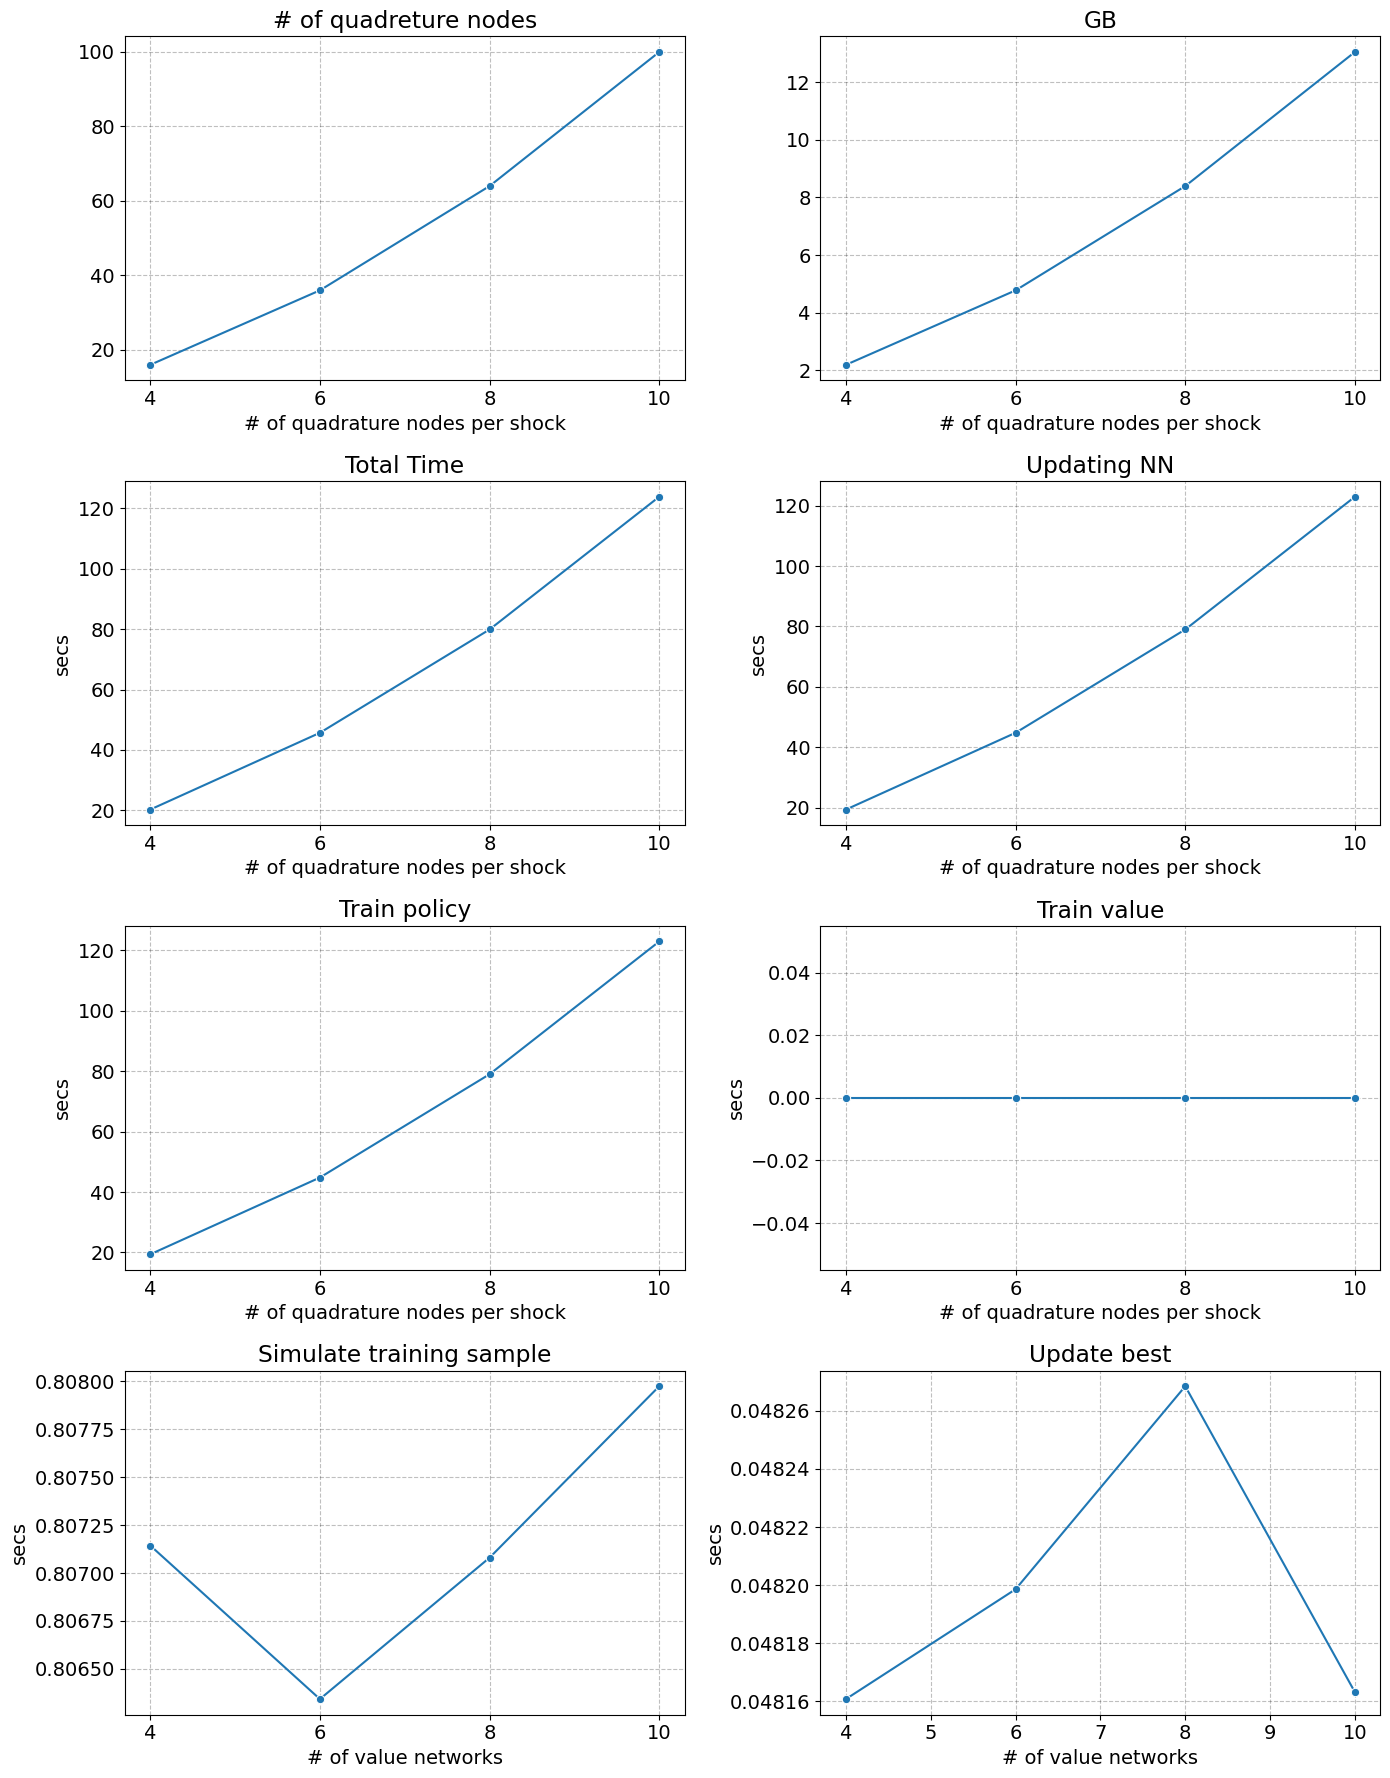

DeepVPD


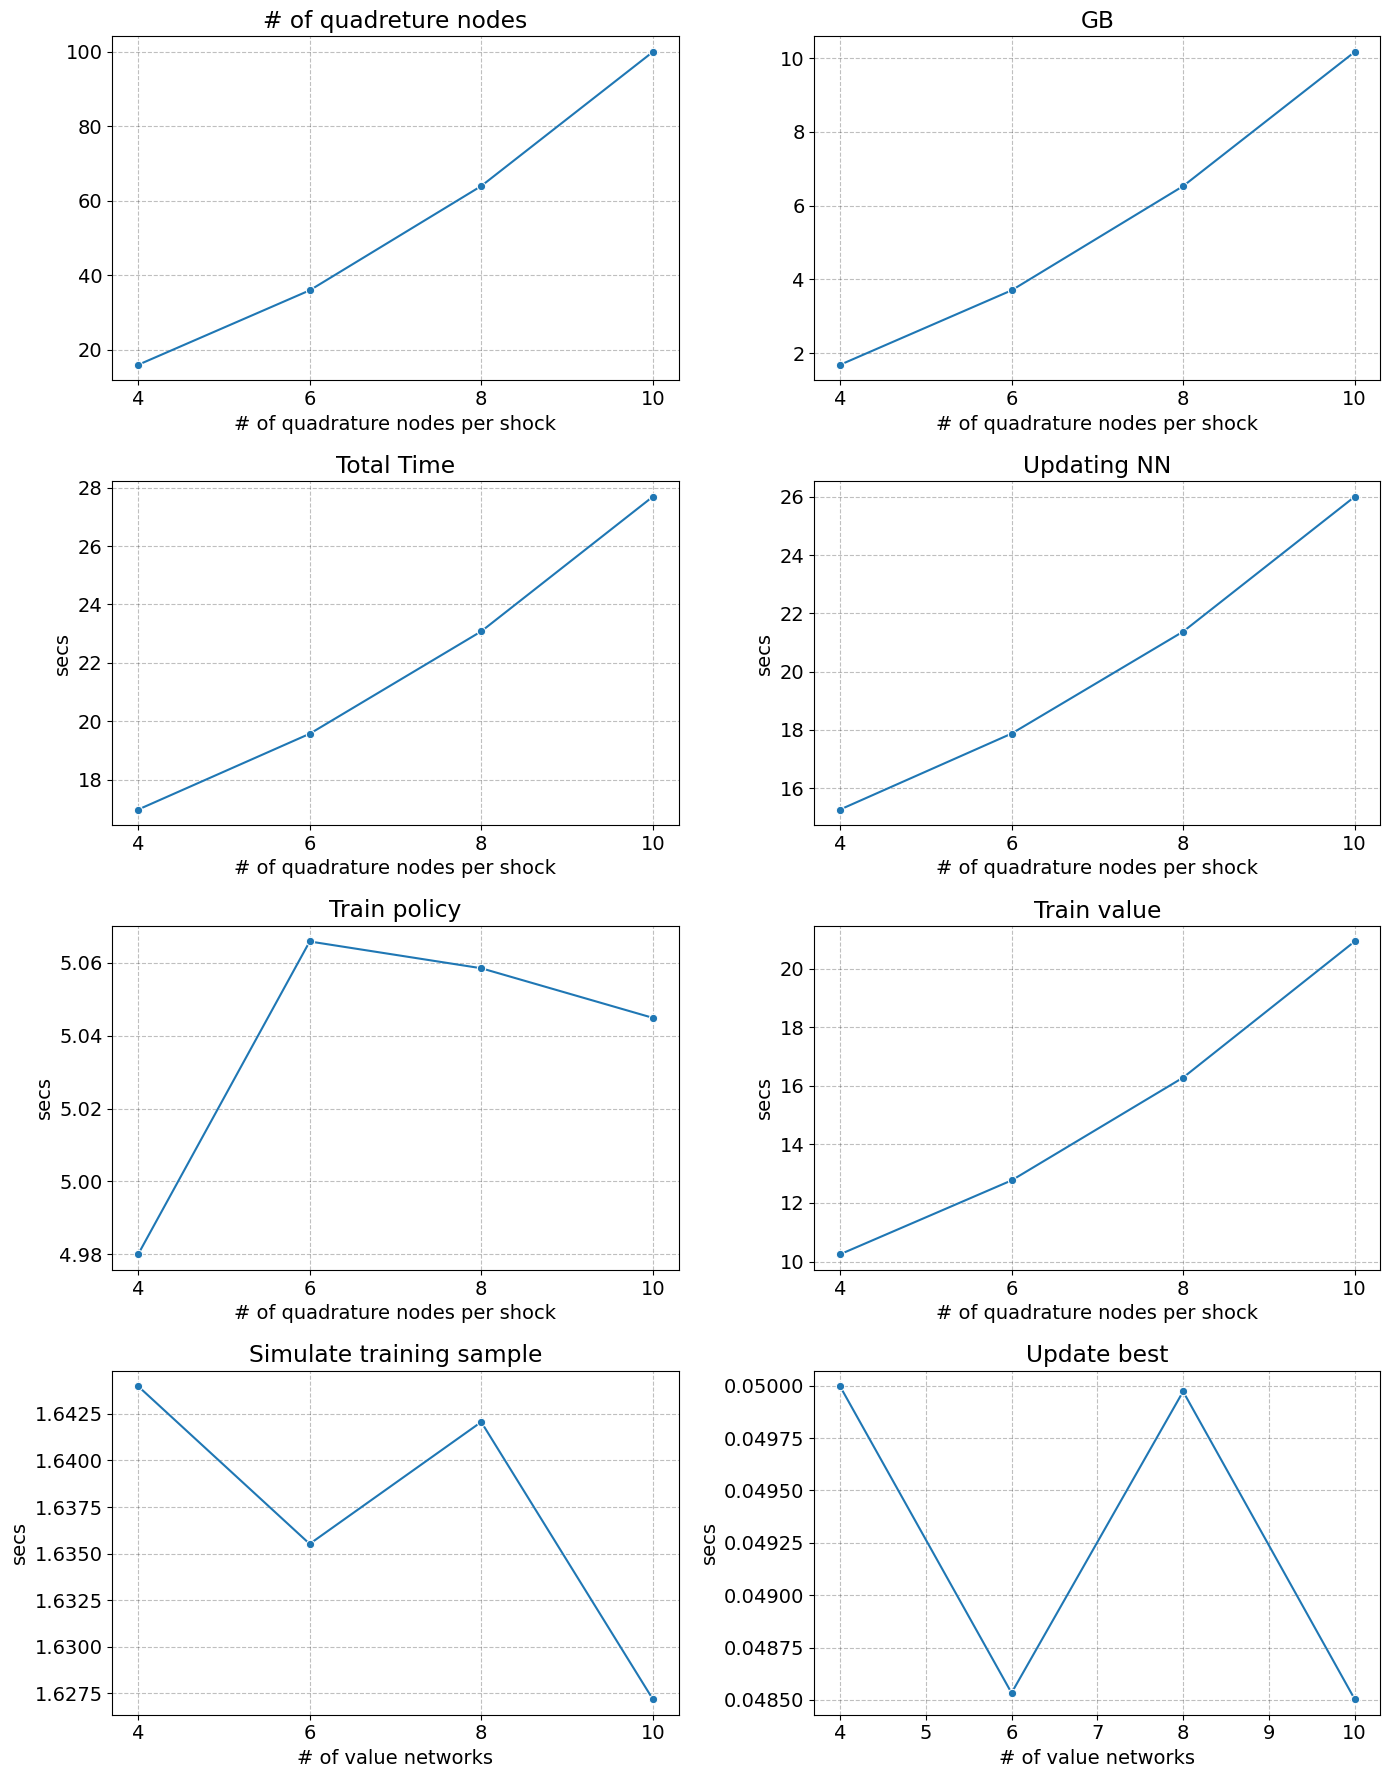

In [19]:
for algo in algonames:

    if algo == 'DeepSimulate': continue
    print(algo)
    
    # get data
    subset = df[df['Algorithm'] == algo]

    # create figure and subplots
    fig, axes = plt.subplots(4,2,figsize=(14,18))

    # epochs
    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='Nnumint_tot',
        marker='o',
        ax=axes[0,0],
    )    
    g.set_xticks(Nnumints)
    axes[0,0].set_title(f'# of quadreture nodes')
    axes[0,0].set_ylabel('')
    axes[0,0].set_xlabel('# of quadrature nodes per shock')
    axes[0,0].grid(True)

    # GB
    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='GB',
        marker='o',
        ax=axes[0,1]
    )
    g.set_xticks(Nnumints)
    axes[0,1].set_title(f'GB')
    axes[0,1].set_ylabel('')
    axes[0,1].set_xlabel('# of quadrature nodes per shock')
    axes[0,1].grid(True)
    
    # Time
    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time',
        marker='o',
        ax=axes[1,0]
    )
    g.set_xticks(Nnumints)
    axes[1,0].set_title(f'Total Time')
    axes[1,0].set_ylabel('secs')
    axes[1,0].set_xlabel('# of quadrature nodes per shock')
    axes[1,0].grid(True)

    g= sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time.update_NN',
        marker='o',
        ax=axes[1,1]
    )
    g.set_xticks(Nnumints)
    axes[1,1].set_title(f'Updating NN')
    axes[1,1].set_ylabel('secs')
    axes[1,1].set_xlabel('# of quadrature nodes per shock')
    axes[1,1].grid(True)  

    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time.update_NN.train_policy',
        marker='o',
        ax=axes[2,0]
    )
    g.set_xticks(Nnumints)
    axes[2,0].set_title(f'Train policy')
    axes[2,0].set_ylabel('secs')
    axes[2,0].set_xlabel('# of quadrature nodes per shock')
    axes[2,0].grid(True)  

    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time.update_NN.train_value',
        marker='o',
        ax=axes[2,1]
    )
    axes[2,1].set_title(f'Train value')
    axes[2,1].set_ylabel('secs')
    axes[2,1].set_xlabel('# of quadrature nodes per shock')
    axes[2,1].grid(True)  
    g.set_xticks(Nnumints)

    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time._simulate_training_sample',
        marker='o',
        ax=axes[3,0]
    )
    g.set_xticks(Nnumints)
    axes[3,0].set_title(f'Simulate training sample')
    axes[3,0].set_ylabel('secs')
    axes[3,0].set_xlabel('# of value networks')
    axes[3,0].grid(True)  

    g = sns.lineplot(
        data=subset, 
        x='Nnumint', 
        y='time.update_best',
        marker='o',
        ax=axes[3,1]
    )
    axes[3,1].set_title(f'Update best')
    axes[3,1].set_ylabel('secs')
    axes[3,1].set_xlabel('# of value networks')
    axes[3,1].grid(True)  

    plt.tight_layout()
    plt.show()